In [1]:
import argparse
import os
import os.path
import sys
import numpy
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import DistanceMetric
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import pickle
import random
import math
from esm.models.esmc import ESMC
from esm.sdk.api import (
    ESM3InferenceClient,
    ESMProtein,
    ESMProteinError,
    LogitsConfig,
    LogitsOutput,
    ProteinType,
)
from Bio import SeqIO
import torch

In [2]:
from protdesignmodules import *

In [3]:
dict_aln=generate_dict_aln("singlesub.faa",'WT',0)

sub_dict=generate_sub_dict(dict_aln)
sub_dict=generate_sub_dict(dict_aln)

mmseq=''.join([dict_aln[x]['aa_type'] for x in dict_aln.keys()])

In [4]:
emb={}
with open("luz_concensussinglemutant_embed_hiddenstates_600m.pkl","rb") as f:
    emb.update(pickle.load(f))

lumidf =pd.read_csv("singlemutant.sorted.values.tsv",sep="\t",header=None)

In [21]:
changedict={}
layerindexlist=[35]
acclist=lumidf[0]
wt=emb['WT.luc_relaxed_complex_A']['hidden_states'][35,0,:,:].to('cuda')

locmut={}
for i in emb.keys():
    diffloc,aa,ori=mutant_loc(emb[i]['sequence'],mmseq)
    locmut.update({i:{
        'locus':diffloc,
        'sub_aa':aa,
        'ori_aa':ori
    }})
    
for i in acclist:
    argval=emb[i]['hidden_states'][35,0,:,:].to('cuda')
    ch={}
    mydata = argval-wt
    mydata=  mydata.detach().to(torch.float).cpu()
    acc=i.split('.')[0]
    #print(acc)
    changedict.update({i:{
                    'diffsub':str(locmut[i]['locus'][0])+locmut[i]['sub_aa'][0] if len(locmut[i]['locus']) > 0 else 'wt',
                    'change':estich(float(lumidf[lumidf[0] == i][1])),
                    'changelevel':float(lumidf[lumidf[0] == i][1]),
                    'emb_change':mydata,
                    'subaa':locmut[i]['sub_aa'][0] if len(locmut[i]['sub_aa']) > 0 else 'wt'
    }})

/tmp/ipykernel_1204030/3427676362.py:24: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

/tmp/ipykernel_1204030/3427676362.py:25: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



In [22]:
selected_loci=np.array([37,170,133,200,208,132,178,198])
selected_loci_acc = [str(x)+'max' for x in selected_loci] + [str(x)+'min' for x in selected_loci] 
change_mat_predict=generate_change_mat(changedict,selected_loci)

torch.Size([58, 250])
Shape of matrix: torch.Size([58, 16])


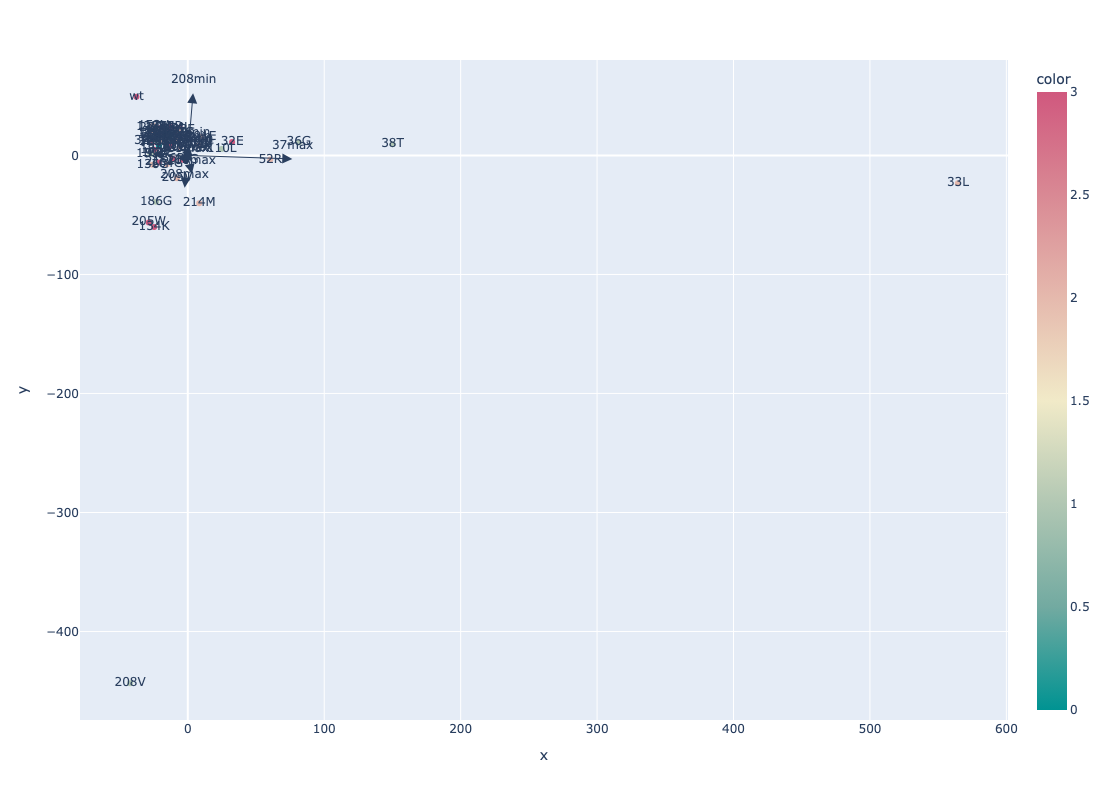

In [23]:

pca = PCA(n_components=2, svd_solver="randomized")
pca.fit(change_mat_predict)


projected_mean_embeddings = pca.transform(change_mat_predict)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
features = selected_loci_acc
#nummut=list(df['adj_mean'])
changetype =[changedict[x]['change'] for x in changedict.keys()]
acc=[changedict[x]['diffsub'] for x in changedict.keys()]
#acc=list(generatesubloc.keys())

# x and y given as array_like objects
import plotly.express as px
fig = px.scatter(x=projected_mean_embeddings[:,0], y=projected_mean_embeddings[:,1],
                 color_continuous_scale=px.colors.diverging.Tealrose,text=acc,color=changetype,
                width=800, height=800)

for i, feature in enumerate(features):
    fig.add_annotation(
        ax=0, ay=0,
        axref="x", ayref="y",
        x=loadings[i, 0],
        y=loadings[i, 1],
        showarrow=True,
        arrowsize=2,
        arrowhead=2,
        xanchor="right",
        yanchor="top"
    )
    fig.add_annotation(
        x=loadings[i, 0],
        y=loadings[i, 1],
        ax=0, ay=0,
        xanchor="center",
        yanchor="bottom",
        text=feature,
        yshift=5,
    )

fig.show()

In [35]:
changetype=[changedict[x]['changelevel'] for x in changedict.keys()]


In [36]:
from sklearn import tree
from sklearn.model_selection import train_test_split
changetype = numpy.log(changetype)
data={'data':change_mat_predict,
     'target':changetype}
X_train, X_test, y_train, y_test = train_test_split(data['data'], data['target'], test_size=.1)
X = X_train
y =y_train


In [37]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
import numpy as np


rng = np.random.RandomState(1)

clf = regr_2 = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=6), n_estimators=300, random_state=rng
)
clf = clf.fit(X, y)
preds=clf.predict(X_test)

pred_df=pd.DataFrame({
    'y_test':y_test,
    'preds':preds,
    'method':'AdaBoostRegressor'
})

from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,preds)


1.125682100862756

In [38]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
import numpy as np


rng = np.random.RandomState(1)

clf = regr_2 = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=6), n_estimators=300, random_state=rng
)
clf = clf.fit(X, y)
preds=clf.predict(X_test)

pred_df=pd.DataFrame({
    'y_test':y_test,
    'preds':preds,
    'method':'AdaBoostRegressor'
})

from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,preds)


1.125682100862756

In [39]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.datasets import make_hastie_10_2

hist = HistGradientBoostingRegressor(max_iter=100).fit(X, y)
hist.score(X_test, y_test)

from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,preds)

pred_df=pd.concat((pred_df,pd.DataFrame({
    'y_test':y_test,
    'preds':preds,
    'method':'HistGradientBoostingRegressor'
})))

from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,preds)


1.125682100862756

In [40]:
from sklearn.datasets import make_regression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

reg = GradientBoostingRegressor(max_depth=6,n_estimators=300,random_state=rng)
reg.fit(X, y)

preds=reg.predict(X_test)

pred_df=pd.concat((pred_df,pd.DataFrame({
    'y_test':y_test,
    'preds':preds,
    'method':'GradientBoostingRegressor'
})))

mean_squared_error(y_test,preds)

0.9199998842167978

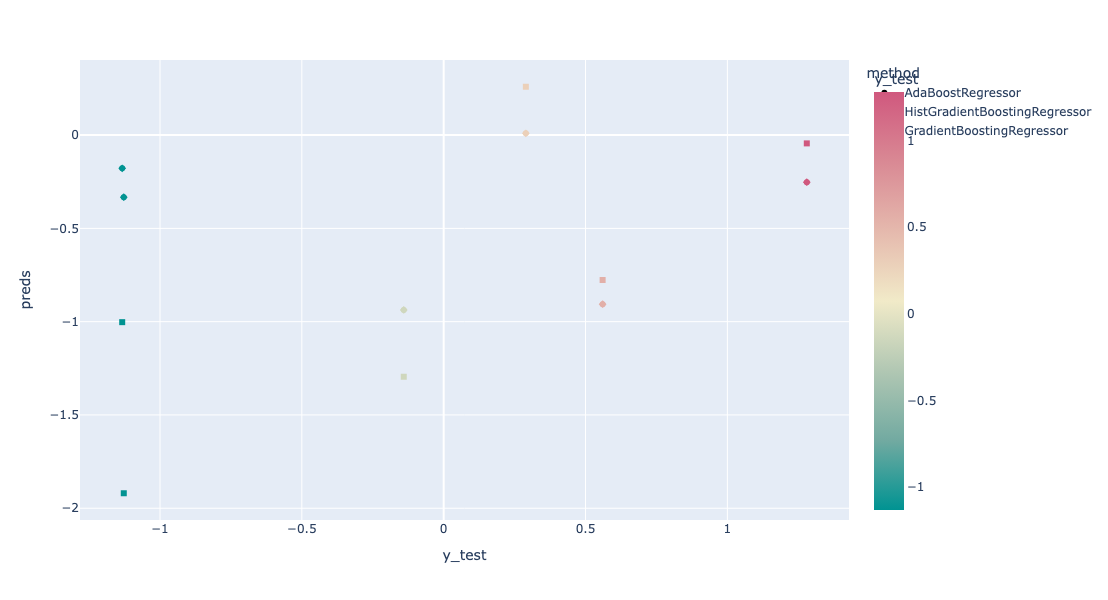

In [41]:
fig = go.Figure()
fig = px.scatter(pred_df,x='y_test', y='preds',
                 color_continuous_scale=px.colors.diverging.Tealrose,color='y_test',
                 symbol='method',
                width=800, height=600)
fig.show()

In [42]:
with open('predictstep_clf.pkl','wb') as f:
    pickle.dump(clf,f)

with open('predictstep_hist.pkl','wb') as f:
    pickle.dump(hist,f)

with open('predictstep_reg.pkl','wb') as f:
    pickle.dump(reg,f)